# Simulation Based Inference to Remove Sampling Bias - inference for both variants jointly

Model  with parameters `beta`, `delta`, `mu_inf_SC`, `mu_inf_SA`, `mu_inf_AI`, `mu_inf_AC`, `mu_inf_AA`, `mu_susc_C`, `mu_susc_A`.

In [1]:
import os
import pickle
from functools import partial
from itertools import product
from time import perf_counter

import bayesflow as bf
import numpy as np
import pandas as pd
import tensorflow as tf
from bayesflow.simulation import GenerativeModel, Prior, Simulator, ContextGenerator
from matplotlib import pyplot as plt
from matplotlib.cm import viridis
from matplotlib.patches import Patch
from tarp import get_tarp_coverage
from tqdm import tqdm

from helper_functions import normalize_household_data
from network_config import load_model
from parameter_cis import sampling_parameter_cis

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
n_procs = int(os.environ.get('SLURM_CPUS_PER_TASK', 1))

In [3]:
train_network = False
presimulate = False
batch_size = 128
iterations_per_epoch = 1000

## Define model and prior

In [4]:
# we assume that besides alpha, if parameters are fixed for one variant, they are fixed for the other variant as well
fixed_parameters = {
    'alpha': {
        "alpha": 0.001,  # baseline infection rate
        "mu_protect_acq": 0.8,  # not enough data to estimate
        "mu_protect_transm": 1.  # not enough data to estimate
    },
    'omicron': {
        #"alpha": 0.002,  # introduces too much variation in the data
        "mu_protect_acq": 0.8,  # not enough data to estimate
        "mu_protect_transm": 0.8  # not enough data to estimate
    }
}
param_names_raw = ['alpha', 'beta', 'delta',
                   'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
                   'mu_susc_C', 'mu_susc_A',
                   'mu_protect_acq', 'mu_protect_transm']
# Drop param names that are in fixed_parameters['alpha']
param_names_a = ['alpha_' + param for param in param_names_raw if param not in fixed_parameters['alpha']]
param_names_o = ['omicron_' + param for param in param_names_raw if param not in fixed_parameters['omicron']]
param_names = param_names_a + param_names_o

mu_count_a = len([param for param in param_names if param.startswith('alpha_mu')])
mu_count_o = len([param for param in param_names if param.startswith('omicron_mu')])
n_params = len(param_names)

In [5]:
# define the prior    
def prior(batch_size: int) -> np.ndarray:
    param_batch = np.zeros((batch_size, n_params))
    
    # alpha wave
    # alpha
    # param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
    # log(beta)
    param_batch[:, 0] = np.random.normal(0, 1, batch_size)
    # delta
    if 'alpha_delta' in param_names:
        param_batch[:, 1] = np.random.normal(0, 1, batch_size)
        #param_batch[:, 1] = np.random.uniform(-3, 3, batch_size)
    # log(mu_...)
    param_batch[:, (len(param_names_a)-mu_count_a):len(param_names_a)] = np.random.normal(0, 1, (batch_size, mu_count_a))
    
    # omicron wave
    # alpha
    #param_batch[:, 0+len(param_names_a)] = np.random.uniform(fixed_parameters['alpha']['alpha'],
    # 0.1, batch_size)
    param_batch[:, 0 + len(param_names_a)] = np.random.beta(2, 2.5, batch_size) * (
                0.03 - fixed_parameters['alpha']['alpha']) + fixed_parameters['alpha']['alpha']
    param_batch[:, 1+len(param_names_a)] = np.random.normal(0, 1, batch_size)
    # delta
    if 'omicron_delta' in param_names:
        param_batch[:, 2+len(param_names_a)] = np.random.normal(0, 1, batch_size)
        #param_batch[:, 1] = np.random.uniform(-3, 3, batch_size)
    # log(mu_...)
    param_batch[:, (len(param_names)-mu_count_o):] = np.random.normal(0, 1, (batch_size, mu_count_o))
    return param_batch

In [6]:
def make_prior_relative(params: np.ndarray) -> np.ndarray:
    params = params.copy()
    # reparameterize, such that omicron parameters are relative to alpha parameters
    for pi, par_name in enumerate(param_names[len(param_names_a):], start=len(param_names_a)):
        # find the corresponding alpha parameter
        alpha_p_name = par_name[len('omicron_'):]
        if alpha_p_name in fixed_parameters['alpha']:
            params[:, pi] = params[:, pi] - fixed_parameters['alpha'][alpha_p_name]
        else:
            params[:, pi] = params[:, pi] - params[:, param_names_a.index('alpha_' + alpha_p_name)]
    return params

def make_prior_absolute(params: np.ndarray) -> np.ndarray:
    params = params.copy()
    # reparameterize, such that omicron parameters are not relative to alpha parameters anymore
    for pi, par_name in enumerate(param_names[len(param_names_a):], start=len(param_names_a)):
        # find the corresponding alpha parameter
        alpha_p_name = par_name[len('omicron_'):]
        if alpha_p_name in fixed_parameters['alpha']:
            if params.ndim == 2:
                params[:, pi] = params[:, pi] + fixed_parameters['alpha'][alpha_p_name]
            else:
                params[:, :, pi] = params[:, :, pi] + fixed_parameters['alpha'][alpha_p_name]
        else:
            if params.ndim == 2:
                params[:, pi] = params[:, pi] + params[:, param_names_a.index('alpha_' + alpha_p_name)]
            else:
                params[:, :, pi] = params[:, :, pi] + params[:, :, param_names_a.index('alpha_' + alpha_p_name)]
    return params

In [7]:
np.random.seed(42)
_prior_draws = prior(1000)
_prior_draws = make_prior_relative(_prior_draws)

# for normalization of the parameters
prior_mean = np.mean(_prior_draws, axis=0)
prior_std = np.std(_prior_draws, axis=0)

assert prior_mean.size == prior_std.size, 'Number of parameters do not match'
assert prior_mean.size == prior(1).shape[1], \
    'Number of parameters do not match in prior'

In [8]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    def simulator_both_variants(log_params: np.ndarray,
                                selection_procedure: str,
                                minimal_length: int,
                                fixed_parameters_dict: dict = None)  -> np.ndarray:
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')
else:
    from Simulator.simulator import simulator_both_variants

# if name starts with mu, create log name
log_param_names = []
for p_name in param_names:
    if p_name == 'alpha_delta' or p_name == 'omicron_delta' or p_name == 'alpha_alpha' or p_name == 'omicron_alpha':
        log_param_names.append(p_name)
    else:
        log_param_names.append(f'log({p_name})')
    
assert n_params == prior_mean.size, 'Number of parameters in normalization do not match names'
print(f"Number of parameters: {n_params}")

Num GPUs Available:  0


Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union


Attaching package: ‘actuar’



    sd, var



    cm




Number of parameters: 19


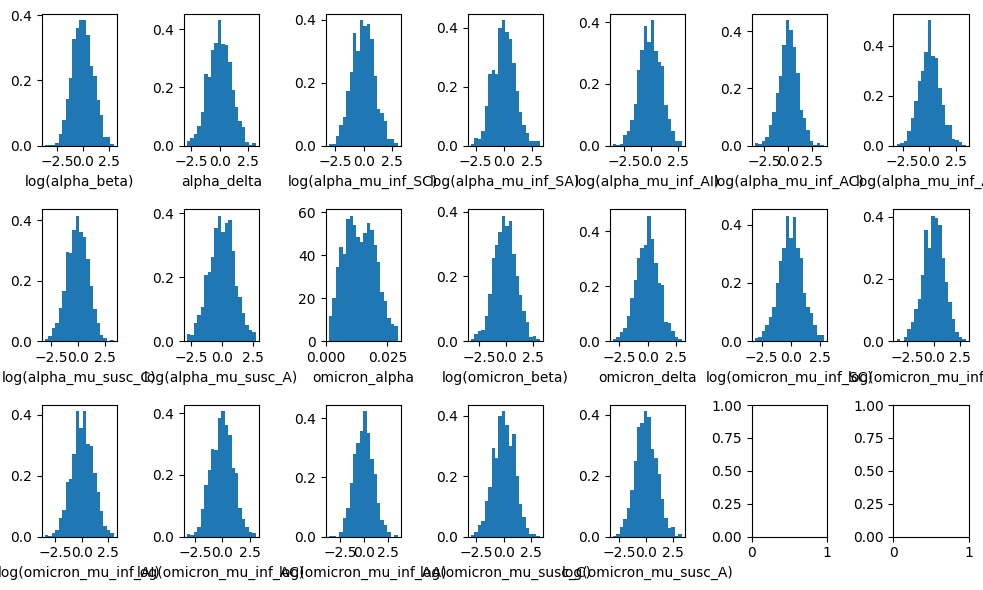

In [9]:
# plot prior
fix, ax = plt.subplots(3, len(log_param_names) // 3+1, figsize=(10, 6), tight_layout=True)
ax = ax.flatten()
n_samples = 1000
prior_samples = prior(n_samples)
prior_samples = make_prior_relative(prior_samples)
prior_samples = make_prior_absolute(prior_samples)
for i in range(len(log_param_names)):
    ax[i].hist(prior_samples[:, i], bins=20, density=True)
    ax[i].set_xlabel(log_param_names[i])
plt.show()

## Define the generative model for BayesFlow

In [10]:
bayesflow_prior = Prior(
    batch_prior_fun=prior,
    param_names=log_param_names
)
gen = ContextGenerator(
    batchable_context_fun=lambda : np.random.choice(['pedcov', 'random']),
)
bayes_simulator = Simulator(
    simulator_fun=partial(simulator_both_variants, fixed_parameters_dict=fixed_parameters),
    context_generator=gen
)
generative_model = GenerativeModel(
    prior=bayesflow_prior, 
    simulator=bayes_simulator,
    skip_test=True
)

## Generate training data

In [11]:
presim_folder = 'presimulations_joint_variants'
#presim_folder = 'presimulations_joint_variants_old_prior_alpha'

if presimulate:    
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    from time import sleep
    sleep(job_array_id)

    for job_1000 in range(10):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        epoch_id = (job_array_id+add_to_id) // iterations_per_epoch
        print(f'presimulating epoch {epoch_id} job {job_array_id+add_to_id}')
        os.makedirs(presim_folder, exist_ok=True)
        generative_model.presimulate_and_save(batch_size=batch_size, 
                                              folder_path=f'{presim_folder}/epoch_{epoch_id}',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    #exit()

In [12]:
# generate validation data
sim_folder = 'sim_data_joint'
#sim_folder = 'sim_data_joint_old_prior_alpha'
valid_file_name = "valid_data_both_variants"

np.random.seed(42)
n_valid = 128
prior_draws = bayesflow_prior(n_valid // 2)
valid_data_dict = {}

for selection in ['pedcov', 'random']:
    
    valid_file_name_vs = f"{valid_file_name}_{selection}"
    if os.path.exists(f'{sim_folder}/{valid_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'rb') as f:
            valid_data_dict[f'{selection}'] = pickle.load(f)
    else:
        print(f"Simulating validation data with {selection}")
        new_valid_data = {
            'prior_draws': prior_draws['prior_draws'].copy(),
            'sim_batchable_context': np.array([[selection] for _ in range(n_valid // 2)]),
        }
        new_valid_data['sim_data'] = np.array([simulator_both_variants(params,
                                                         selection_procedure=selection,
                                                         fixed_parameters_dict=fixed_parameters)
                                               for params in new_valid_data['prior_draws']])
        # save the data
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_valid_data, f)
        valid_data_dict[f'{selection}'] = new_valid_data

# we cannot use both variants at the same time for validation since not batchable
valid_data = {key: np.concatenate((valid_data_dict['pedcov'][key],
                                   valid_data_dict['random'][key])
                                  ) for key in valid_data_dict['pedcov'].keys()}

In [23]:
def renormalize_params(params: np.ndarray, keep_transform: bool = False, keep_log_transform: bool = False) -> np.ndarray:
    un_scaled_params = params.copy()
    un_scaled_params = un_scaled_params * prior_std + prior_mean
    
    if keep_transform and keep_log_transform:  # keep all transformations
        return un_scaled_params
    
    if not keep_transform and keep_log_transform:  # remove only the relative transformation
        un_scaled_params = make_prior_absolute(un_scaled_params)
        return un_scaled_params
    
    if not keep_transform:  # remove all transformations
        un_scaled_params = make_prior_absolute(un_scaled_params)
        
        for p_i in range(n_params):
            if log_param_names[p_i][:3] != 'log':
                continue
                
            if un_scaled_params.ndim == 2:
                un_scaled_params[:, p_i] = np.exp(un_scaled_params[:, p_i])
            elif un_scaled_params.ndim == 3:
                 un_scaled_params[:, :, p_i] = np.exp(un_scaled_params[:, :, p_i])
            else:
                raise ValueError('Invalid number of dimensions')
    return un_scaled_params

## Define the neural network architectures

In [14]:
# settings
#net_id = 5  # 5 for both selection methods, 7 for only PedCov (old prior alpha)
net_id = 5  # 5 for both selection methods, 9 for only PedCov

amortizer_folder = 'amortizer_joint'
#amortizer_folder = 'amortizer_joint_old_prior_alpha'

trainer, amortizer_name = load_model(
    model_id=net_id,
    n_params=n_params,
    generative_model=generative_model,
    prior_mean=prior_mean,
    prior_std=prior_std,
    train_network=train_network,
    valid_data=valid_data,
    presim_folder=presim_folder,
    amortizer_folder=amortizer_folder,
    make_prior_relative=make_prior_relative,
    amortizer_return_attention_weights=False
)

amortizer_joint/amortizer-sampling-bias-both_variants-8-attention


INFO:root:Loaded loss history from amortizer_joint/amortizer-sampling-bias-both_variants-8-attention/history_250.pkl.
INFO:root:Networks loaded from amortizer_joint/amortizer-sampling-bias-both_variants-8-attention/ckpt-250


Networks loaded from amortizer_joint/amortizer-sampling-bias-both_variants-8-attention/ckpt-245
Best validation loss: 8.12728214263916


## Check the training convergence

In [15]:
results_folder = 'results_joint_variants'
#results_folder = 'results_joint_variants_old_prior_alpha'
os.makedirs(results_folder, exist_ok=True)

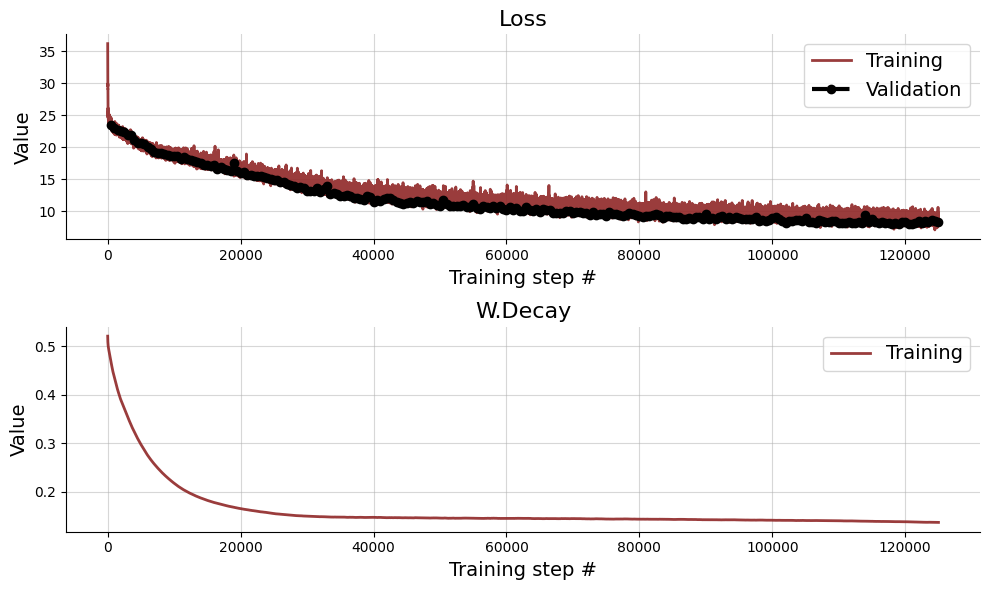

In [16]:
history = trainer.loss_history.get_plottable()
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [17]:
test_sims = trainer.configurator(valid_data)

In [18]:
# we need to join samples from both variants to check SBC and other diagnostics
posterior_samples = trainer.amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples, keep_transform=True)

prior_draws = renormalize_params(test_sims["parameters"], keep_transform=True)

In [ ]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=log_param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_sbc.png')

In [ ]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=log_param_names);

In [ ]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=log_param_names);

In [ ]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', 
                                         metric='euclidean', norm=True, bootstrap=True)

In [ ]:
k_sigma = [1, 2, 3]

_, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# Test inference on synthetic data for both recruitment scenarios and variants

In [ ]:
n_samples = 100

test_scenarios_posterior_samples = {}
for test_scenario in valid_data_dict.keys():
    print(f"Testing scenario {test_scenario}")
    test_sims = trainer.configurator(valid_data_dict[test_scenario])
    posterior_samples = trainer.amortizer.sample(test_sims, n_samples=n_samples)
    posterior_samples = renormalize_params(posterior_samples, keep_transform=True)
    test_scenarios_posterior_samples[test_scenario] = posterior_samples
    prior_draws = renormalize_params(test_sims["parameters"], keep_transform=True)
    fig = bf.diagnostics.plot_recovery(posterior_samples, prior_draws,
                                       ylabel=f'Estimated\n{test_scenario}',
                                       param_names=log_param_names)
    fig.savefig(f'{results_folder}/{amortizer_name}_recovery_{test_scenario}.png')
    plt.show()

### Check summary statistics in latent space

One should not be able to distinguish between the two variants or the scenarios in the latent space.
This is a good sign that the amortizer is working correctly.
Later we can test if the real data is also indistinguishable in the latent space.


In [ ]:
if trainer.amortizer.summary_loss is not None:
    np.random.seed(0)
    sim_id = np.random.randint(0, n_valid // 4)
    for selection in ['pedcov', 'random']:
        test_sims = trainer.configurator(valid_data_dict['pedcov'])
        test_sims_rand = trainer.configurator(valid_data_dict[f'{selection}'])

        MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
            observed_data=test_sims_rand["summary_conditions"][sim_id][np.newaxis],
            reference_data=test_sims,  # if not provided, will use the generative model
            num_null_samples=1000,
            bootstrap=True  # if True, use the reference data as null samples
        )
        fig = bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
        plt.title(f"MMD Hypothesis Test ({selection})")
        #fig.savefig(f'{results_folder}/{amortizer_name} MMD.png', bbox_inches='tight')
        plt.show()

## Bias Estimation

bias found in simulation study (when using PedCov as selection procedure) with MCMC:
- overestimation of mu_inf_SA, mu_inf_AA (infectiousness of adults)
- underestimation of mu_susc_A (susceptibility of adults)

Here we should not see any bias anymore, since we condition on the recruitment procedure and variant.

### Simulation Study

All parameters are set to 1 besides one parameter. Inference workflow applied on the full model still. Check if for the changing parameter the true parameter is still recovered.

Here we tell the network the right selection procedure. Results should be not be biased for no selection procedure. 

In [ ]:
# generate simulation study or load data
simulation_study_file_name = "sim_study_data_both_variants"
n_sims_per_param = 50

np.random.seed(42)
prior_draws_sim_study = bayesflow_prior(n_sims_per_param)['prior_draws']
non_fix_indices_study = np.arange(n_params)
fix_indices_study = np.array([param_names.index('alpha_beta'),
                       param_names.index('alpha_delta'),
                       param_names.index('omicron_alpha'),
                       param_names.index('omicron_beta'),
                       param_names.index('omicron_delta')])
non_fix_indices_study = np.delete(non_fix_indices_study, fix_indices_study)
prior_draws_sim_study[:, fix_indices_study] = np.array([np.log(0.2), 1.3, 0.002, np.log(0.2), 1.3])

sim_study_dict = {}
sim_study_bias_dict = {}

for selection in ['pedcov', 'random']:
    
    study_file_name_vs = f"{simulation_study_file_name}_{selection}"
    if os.path.exists(f'{sim_folder}/{study_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'rb') as f:
            sim_study_dict[f'{selection}'] = pickle.load(f)
    else:
        print(f"Simulating simulation study with {selection}")
        new_sim_data = {
            'prior_draws': np.zeros((len(non_fix_indices_study), n_sims_per_param, n_params)),  # all parameters are set to log(1)
            'sim_batchable_context': np.array([[[selection] for _ in range(n_sims_per_param)]
                                               for _ in range(len(non_fix_indices_study))]),
            'sim_data': np.empty((len(non_fix_indices_study), n_sims_per_param,
                                  valid_data_dict[f'{selection}']['sim_data'].shape[1],
                                  valid_data_dict[f'{selection}']['sim_data'].shape[2], 
                              valid_data_dict[f'{selection}']['sim_data'].shape[3])),
        }
        for i, index_i in enumerate(non_fix_indices_study):
            # set all except the i-th parameter to log(1)
            new_sim_data['prior_draws'][i, :, index_i] = prior_draws_sim_study.copy()[:, index_i]
            new_sim_data['prior_draws'][i, :, fix_indices_study] = prior_draws_sim_study.copy()[:, fix_indices_study].T  # fix params
            new_sim_data['sim_data'][i] = np.array([simulator_both_variants(params,
                                                                           selection_procedure=selection,
                                                                           fixed_parameters_dict=fixed_parameters) 
                                                      for params in new_sim_data['prior_draws'][i]])
        # save the data
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_sim_data, f)
        sim_study_dict[f'{selection}'] = new_sim_data

In [ ]:
# perform inference on simulation study
results_sim_study = {} 
n_samples_study = 1000 # increase for more accurate results, e.g. 1000 samples

for selection_data, selection_inference in tqdm(product(['pedcov', 'random'], ['pedcov', 'random']), total=4):
    # estimate median and CI for each parameter
    results_sim_study_vs = {
        'posterior_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
        'posterior_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
        'relative_bias_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
        'relative_bias_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
        'overall_median_error': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
    }
    for i, index_i in enumerate(non_fix_indices_study):
        # get data for this parameter
        sim_study_i = {
            'sim_data': sim_study_dict[f'{selection_data}']['sim_data'][i],
            'prior_draws': sim_study_dict[f'{selection_data}']['prior_draws'][i],
            # on purpose a different selection procedure than the data was generated with
            'sim_batchable_context': sim_study_dict[f'{selection_inference}']['sim_batchable_context'][i],
        }
        simulation_study_data_conf = trainer.configurator(sim_study_i)
        # get posterior samples
        posterior_samples_sim_study = (
            trainer.amortizer.sample(simulation_study_data_conf, n_samples=n_samples_study)
        )
        posterior_samples_sim_study = renormalize_params(posterior_samples_sim_study, keep_transform=False)
        prior_draws_study = renormalize_params(simulation_study_data_conf['parameters'], keep_transform=False)

        # get median and CI for each parameter of posterior samples
        # we only care about the changing parameter, the others are set to 1
        results_sim_study_vs['posterior_median'][i] = np.median(posterior_samples_sim_study[:, :, index_i], axis=1)
        results_sim_study_vs['posterior_CI'][i] = np.quantile(posterior_samples_sim_study[:, :, index_i],
                                                                           [0.005, 0.025, 0.1,
                                                                            0.995, 0.975, 0.9],
                                                                           axis=1)
        # get median and CI for each parameter of relative bias (estimate - true) / true
        relative_bias = (posterior_samples_sim_study[:, :, index_i] - prior_draws_study[:, index_i][:, np.newaxis]) / prior_draws_study[:, index_i][:, np.newaxis]
        results_sim_study_vs['relative_bias_median'][i] = np.median(relative_bias, axis=1)
        results_sim_study_vs['relative_bias_CI'][i] = np.quantile(relative_bias,
                                                                               [0.005, 0.025, 0.1,
                                                                                0.995, 0.975, 0.9],
                                                                               axis=1)
        # order the relative bias by size of the true parameters
        ordering = np.argsort(sim_study_i['prior_draws'][:, index_i])
        results_sim_study_vs['relative_bias_median'][i] = results_sim_study_vs['relative_bias_median'][i][ordering]
        results_sim_study_vs['relative_bias_CI'][i] = results_sim_study_vs['relative_bias_CI'][i][:, ordering]

        # get overall median error
        results_sim_study_vs['overall_median_error'][i] = np.sum(
            (np.median(posterior_samples_sim_study, axis=1) - prior_draws_study)**2, axis=1
        )

    results_sim_study[f'{selection_data}_{selection_inference}'] = results_sim_study_vs

In [ ]:
# plot the results
prior_transformed = renormalize_params(prior_draws_sim_study, keep_transform=False)

for selection_data, selection_inference in product(['pedcov', 'random'], ['pedcov', 'random']):
    fig, ax = plt.subplots(2, 7, sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
    space = 1. / n_sims_per_param
    ci_level = 0.95
    ci_interval = {0.99: [0, 3], 0.95: [1, 4], 0.8: [2, 5]}[0.95]
    colors = ['#1f78b4', '#b2df8a']
    
    handles = ['', '']
    handles_mean = ['', '']
    for j, variant in enumerate(['alpha', 'omicron']):
        i_plot = 0
        for i_total, index_i in enumerate(non_fix_indices_study):
            prior_ordered = np.sort(prior_transformed[:, index_i])
            
            if variant == 'alpha':
                if param_names[index_i] not in param_names_a:
                    continue
            else:
                if param_names[index_i] not in param_names_o:
                    continue

            relative = results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_median'][i_total]

            handles[j] = ax[j, i_plot].errorbar(prior_ordered,
                                                relative,
                                                yerr=np.abs(results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_CI'][i_total][ci_interval] - results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_median'][i_total]),
                                                fmt='o', color=colors[j], alpha=0.7, label=f'{variant}')
            handles_mean[j] = ax[j, i_plot].errorbar(2.5,
                                                     np.median(relative),
                                                     yerr=np.std(relative),
                                                     color='black', marker='x', label=r'Median bias ($\pm$ std)', zorder=4)

            ax[j, i_plot].axhline(0, color='black', ls='--', zorder=3)
            ax[1, i_plot].set_xlim(-0.5, 5.5)
            ax[1, i_plot].set_xticks(np.arange(6))
            if j == 0:
                ax[1, i_plot].set_xlabel(param_names_raw[index_i+1])  # raw has still alpha in it
            i_plot += 1
    ax[0, 0].set_ylabel(f'Relative Bias\n(Median, {round(ci_level*100)}% CI)')
    ax[1, 0].set_ylabel(f'Relative Bias\n(Median, {round(ci_level*100)}% CI)')
    ax[0, 7//2].set_title(f'Simulation Study - Data: {selection_data}, Inference: {selection_inference}')
    ax[0, 0].set_ylim(-1.5, 10)
    fig.legend(handles=handles+[handles_mean[0]],
                loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_'
                f'{selection_data}_vs_inference_{selection_inference}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# plot bias in both scenarios
fig, ax = plt.subplots(2, len(non_fix_indices_study) // 2, sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
colors = ['#d95f02', '#7570b3']
ax = ax.flatten()

for j, (selection_data, selection_inference) in enumerate(product(['pedcov', 'random'], ['pedcov', 'random'])):
    for i, index_i in enumerate(non_fix_indices_study):
        # plot a line around 0
        ax[i].axhline(0, color='black', ls='--', zorder=3)

        relative = results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_median'][i]

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(relative, [0.025, 0.975])
        yerr_alpha = np.array([[np.median(relative) - lower_quantile],
                               [upper_quantile - np.median(relative)]])
        handle_mean = ax[i].errorbar(j,
                                     np.median(relative),
                                     yerr=yerr_alpha,
                                     color=colors[j // 2], marker='x', label=r'Median Bias', zorder=4)
        ax[i].set_title(param_names[index_i])
        ax[i].set_xlim(-0.5, 3.5)
        ax[i].set_xticks([0, 1, 2, 3], labels=['PedCov', 'Random', 'PedCov', 'Random'], rotation=60)
        ax[0].set_ylabel('Median Relative Bias')

color_patch = [Patch(color=colors[i], label=f'Data generated with {["PedCov", "Random"][i]}') for i in range(2)]
leg = fig.legend(handles=color_patch, bbox_to_anchor=(0.5, -0.05), loc='lower center', ncol=2)
fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_bias.png', bbox_inches='tight')
plt.show()

# Apply inference on real data

In [19]:
# specify the data path
data_path_alpha = 'data/simulated_data_formatted_alpha_rnd_1.txt'  # todo: exchange with real data of alpha
data_path_omicron = 'data/simulated_data_formatted_alpha_rnd_1.txt'  # todo: exchange with real data of omicron
os.makedirs(results_folder+'/real data', exist_ok=True)

In [20]:
# load the data
dfs = {
    'alpha': pd.read_csv(data_path_alpha, delimiter=' ', index_col=0),
    'omicron': pd.read_csv(data_path_omicron, delimiter=' ', index_col=0)
}
prior_samples = renormalize_params(prior(1000))

# prepare the data for neural networks and concatenate both variants
household_data = []
n_households = []
for variant in ['alpha', 'omicron']:
    household_data_v = normalize_household_data(dfs[variant], minimal_length=9)
    n_households.append(household_data_v.shape[0])
     # add variant as feature
    if variant == 'alpha':
        variant_feature = np.zeros((household_data_v.shape[0], 9, 1))
    else:
        variant_feature = np.ones((household_data_v.shape[0], 9, 1))
    household_data_v = np.concatenate((household_data_v, variant_feature), axis=-1)
    household_data.append(household_data_v)   
household_data = np.concatenate(household_data, axis=0)[np.newaxis]

real_data = {
    'sim_data': household_data,
    'sim_batchable_context': 'pedcov'
}
real_data.update({'configured_data': trainer.configurator(real_data)})

In [24]:
# get posterior samples
posterior_samples_real = (
    trainer.amortizer.sample(real_data['configured_data'], n_samples=prior_samples.shape[0])
)
real_data['configured_data']['parameters'] = posterior_samples_real[np.newaxis]
real_data['posterior_samples'] = renormalize_params(posterior_samples_real)
posterior_samples_test_pair = renormalize_params(posterior_samples_real, keep_log_transform=False, keep_transform=True)

# compute MAP
posterior_samples_prop = (
    trainer.amortizer.log_posterior(real_data['configured_data'])
)
real_data['MAP'] = renormalize_params(posterior_samples_real[np.argmax(posterior_samples_prop)][np.newaxis],
                                      keep_log_transform=True)[0]

In [ ]:
# plot posterior samples vs prior
fig = bf.diagnostics.plot_posterior_2d(
    posterior_draws=real_data['posterior_samples'][:100],
    prior_draws=prior_samples[:100],
    param_names=param_names,
    label_fontsize=22,
    legend_fontsize=24
)
ax = fig.get_axes()
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names)+1):
        a.axvline(1, color='b')
plt.savefig(f'{results_folder}/real data/posterior_{variant}.png', bbox_inches='tight')
plt.show()

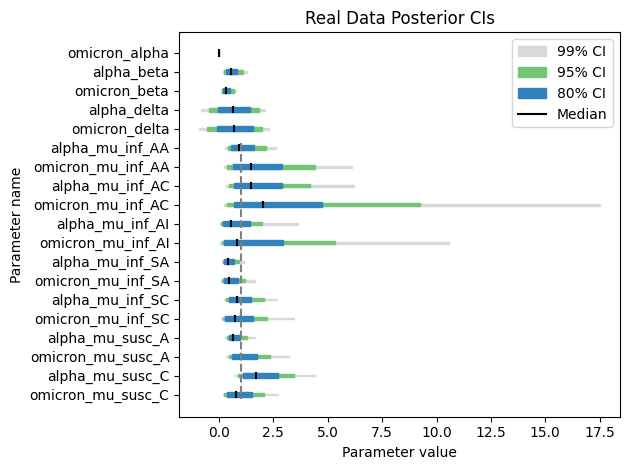

In [22]:
# Sort based on the part after the first underscore
sorted_indices = [param_names.index(variant) for variant in sorted(param_names, key=lambda x: x.split('_', 1)[1])]

# plot credible intervals for each parameter and each variant
ax = sampling_parameter_cis(real_data['posterior_samples'][:, sorted_indices], alpha=[99, 95, 80],
                            param_names=np.array(param_names)[sorted_indices],
                            title=f"Real Data Posterior CIs")
# add vertical line at 1 for the mu parameters
ax.vlines(1, ymin=4.75, ymax=18.25, color='grey', linestyle='--')
plt.savefig(f'{results_folder}/real data/CIs_both.png', bbox_inches='tight')
plt.show()

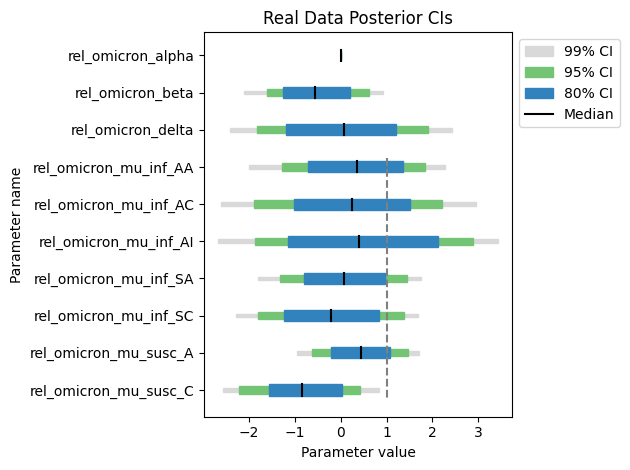

In [46]:
# parameters for omicron are significantly different from alpha if their ratio is not 1
test_names = np.array(param_names)[sorted_indices]
relative_params_index = [i for i, p in enumerate(test_names) if 'omicron' in p]
test_names = np.array(['rel_' + p for p in test_names])

# plot credible intervals for each parameter and each variant
ax = sampling_parameter_cis(posterior_samples_test_pair[:, sorted_indices][:, relative_params_index],
                            alpha=[99, 95, 80],
                            param_names=test_names[relative_params_index],
                            title=f"Real Data Relative Posterior CIs")
# add vertical line at 1 for the mu parameters
ax.vlines(1, ymin=2.75, ymax=9.25, color='grey', linestyle='--')
plt.savefig(f'{results_folder}/real data/CIs_relative.png', bbox_inches='tight')
plt.show()

In [ ]:
if trainer.amortizer.summary_loss is not None:
    colors = viridis(np.linspace(0.1, 0.9, 2))

    # check latent space as well, distribution can be different but still in-sample
    ref_data = trainer.configurator(valid_data_dict['pedcov'])["summary_conditions"]
    summary_statistics = trainer.amortizer.summary_net(ref_data)
    summary_statistics_obs = trainer.amortizer.summary_net(real_data['configured_data']["summary_conditions"])

    fig, ax = plt.subplots(1, 1, figsize=(4, 4), tight_layout=True)
    ax.scatter(
        summary_statistics_obs[:, 0], summary_statistics_obs[:, 1], color=colors[0], label=r"Observed: $h_{\psi}(x_{obs})$"
    )
    ax.scatter(summary_statistics[:, 0], summary_statistics[:, 1], color=colors[1], label=r"Well-specified: $h_{\psi}(x)$")
    ax.legend(loc='upper right')
    ax.grid(alpha=0.2)
    plt.gca().set_aspect("equal")
    plt.title(f"Latent Space for Real Data")
    plt.savefig(f'{results_folder}/real data/latent_space_{variant}.png', bbox_inches='tight')
    plt.show()

    # check the summary statistics
    MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
        observed_data=real_data['configured_data']["summary_conditions"],
        reference_data=trainer.configurator(valid_data_dict['pedcov']),  # test against pedcov
        bootstrap=True,  # if True, use the reference data as null samples,
        num_null_samples=1000,
    )
    bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
    plt.title("MMD Hypothesis Test for Real Data")
    plt.savefig(f'{results_folder}/real data/MMD_{variant}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# compute statistics for real data and the simulation study
# compute number of infected individuals based on age, household size
from helper_functions import get_household_statistic

real_data_stats = {
    'alpha': None,
    'omicron': None
}

sim_data_stats = {
    'alpha': None,
    'omicron': None
}
status_names = ['not_infected', 'infected_symptomatic', 'infected_asymptomatic']
colors_age = {
    '<6 years': '#b2df8a',
    '6-11 years': '#d95f02',
    '>11 years': '#1f78b4'
}
colors_status = {
    'infected_symptomatic': '#1f78b4',
    'infected_asymptomatic': '#b2df8a'
}


# original_pedcov is pedcov selection, but tries to get unique households (so exactly the same as real data)
sim_data_map = simulator_both_variants(log_params=real_data['MAP'],
                                       selection_procedure='original_pedcov',
                                       fixed_parameters_dict=fixed_parameters)
sim_data_stats.update({'sim_data_map': sim_data_map})

real_data_stats['alpha'] = get_household_statistic(real_data['sim_data'][0][:n_households[0]])
real_data_stats['omicron'] = get_household_statistic(real_data['sim_data'][0][n_households[0]:])
sim_data_stats['alpha'] = get_household_statistic(sim_data_map[:n_households[0]])
sim_data_stats['omicron'] = get_household_statistic(sim_data_map[n_households[0]:])

In [ ]:
# plot the distribution of number of infected individuals
for variant in ['alpha', 'omicron']:
    print(f"Variant: {variant}")
    fig, ax = plt.subplots(2, len(real_data_stats[variant]['household_sizes']), 
                           sharex=True, sharey='col', tight_layout=True, figsize=(12, 8))
    for i, household_size in enumerate(real_data_stats[variant]['household_sizes']):
        bottom = {0: 0, 1: 0, 2: 0}
        for age_group in real_data_stats[variant]['infection_counts'].index:
            infected_dict = real_data_stats[variant]['infection_counts'].loc[age_group, household_size]
            if not isinstance(infected_dict, dict):
                continue
            ax[0, i].bar(infected_dict.keys(), infected_dict.values(), 
                      bottom=[bottom[k] for k in infected_dict.keys()], 
                      alpha=0.5, label=age_group, color=colors_age[age_group])
            bottom.update({k: bottom[k] + infected_dict[k] for k in infected_dict.keys()})
        ax[0, i].set_title(f'Household Size {household_size}')
        
    for i, household_size in enumerate(real_data_stats[variant]['household_sizes']):
        bottom = {0: 0, 1: 0, 2: 0}
        for age_group in sim_data_stats[variant]['infection_counts'].index:
            infected_dict = sim_data_stats[variant]['infection_counts'].loc[age_group, household_size]
            if not isinstance(infected_dict, dict):
                continue
            ax[1, i].bar(infected_dict.keys(), infected_dict.values(), 
                      bottom=[bottom[k] for k in infected_dict.keys()], 
                      alpha=0.5, label=age_group, color=colors_age[age_group])
            bottom.update({k: bottom[k] + infected_dict[k] for k in infected_dict.keys()})
        ax[1, i].set_xticks(ticks=[0,1,2], labels=status_names, rotation=45)
            
    ax[0, 0].set_ylabel('Frequency (Real Data)')
    ax[1, 0].set_ylabel('Frequency (Sim Data)')
    handles = [Patch(facecolor=color, label=age_group, alpha=0.5) for age_group, color in colors_age.items()]
    fig.legend(handles, colors_age.keys(), 
               loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    plt.savefig(f'{results_folder}/real data/number_infections_{variant}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# plot the distribution of infection times
for variant in ['alpha', 'omicron']:
    for cofactor_type in ['time_distribution', 'time_distribution_age']:
        colors = colors_age if cofactor_type == 'time_distribution_age' else colors_status
        print(f"Variant: {variant}")
        fig, ax = plt.subplots(2, len(real_data_stats[variant]['household_sizes']), 
                               sharex='col', sharey='col', tight_layout=True, figsize=(12, 8))
        for i, household_size in enumerate(real_data_stats[variant]['household_sizes']):
            for status in real_data_stats[variant][cofactor_type].index:
                if status == 'not_infected':
                    continue
                infection_times = np.array(real_data_stats[variant][cofactor_type].loc[status, household_size])
                if np.isnan(infection_times).all():
                    continue
                ax[0, i].hist(infection_times*1000, bins=10, alpha=0.5, label=status, color=colors[status])
            ax[0, i].set_title(f'Household Size {household_size}')
            
            for status in sim_data_stats[variant][cofactor_type].index:
                if status == 'not_infected':
                    continue
                infection_times = np.array(sim_data_stats[variant][cofactor_type].loc[status, household_size])
                if np.isnan(infection_times).all():
                    continue
                ax[1, i].hist(infection_times*1000, bins=10, alpha=0.5, label=status, color=colors[status])
            ax[1, i].set_xlabel('Infection Date')
            
        ax[0, 0].set_ylabel('Frequency (Real Data)')
        ax[1, 0].set_ylabel('Frequency (Sim Data)')
        handles = [Patch(facecolor=color, label=status, alpha=0.5) for status, color in colors.items()]
        fig.legend(handles, colors.keys(), 
                   loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
        plt.savefig(f'{results_folder}/real data/infection_time_points_{variant}_{cofactor_type}.png', 
                    bbox_inches='tight')
        plt.show()